In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Obter os registros de benchmark.
df_google = pd.read_csv('Google_robot_benchmark_Simpler_Env_Gr00t.csv')
df_widowx = pd.read_csv('WidowX_robot_benchmark_Simpler_Env_Gr00t.csv')

# Adicionar uma coluna 'robot' para identificar o robô.
df_widowx['robot'] = 'WidowX Robot'
df_google['robot'] = 'Google Robot'

# Obter todas as colunas que são tarefas, excluindo as que não são (checkpoint, robot, media)
non_task_cols = ['checkpoint', 'robot']

google_task_cols = [col for col in df_google.columns if col not in non_task_cols]
widowx_task_cols = [col for col in df_widowx.columns if col not in non_task_cols]

# Preparar dados para média de desempenho
df_avg_comparison = pd.concat([
    df_google[['checkpoint', 'robot']],
    df_widowx[['checkpoint', 'robot']]
])

df_widowx_melted = df_widowx[['checkpoint', 'robot'] + widowx_task_cols].melt(
    id_vars=['checkpoint', 'robot'], var_name='Tarefa', value_name='Taxa de Sucesso'
)

df_google_melted = df_google[['checkpoint', 'robot'] + google_task_cols].melt(
    id_vars=['checkpoint', 'robot'], var_name='Tarefa', value_name='Taxa de Sucesso'
)

display(df_google.head())
display(df_widowx.head())

,checkpoint,pick_coke_can,pick_object,move_near,open_drawer,close_drawer,place_in_closed_drawer,robot
0,GR00T N1.6,97.5,87.0,75.5,44.0,87.5,14.5,Google Robot
1,GR00T N1.7,97.9,87.7,94.8,44.6,53.1,19.0,Google Robot


,checkpoint,spoon_on_towel,carrot_on_plate,put_eggplant_in_basket,stack_cube,put_eggplant_in_sink,close_drawer,open_drawer,robot
0,GR00T N1.6,64.5,65.5,93.0,5.5,40.0,70.5,95.5,WidowX Robot
1,GR00T N1.7,83.1,64.2,48.9,41.6,2.9,97.4,99.9,WidowX Robot


### Adicionando colunas de Média e Desvio Padrão aos DataFrames

In [19]:
# Calcular a média e o desvio padrão da 'Taxa de Sucesso' para df_google_melted por checkpoint
df_google_stats = df_google_melted.groupby('checkpoint')['Taxa de Sucesso'].agg(['mean', 'std']).reset_index()
df_google_stats.rename(columns={'mean': 'mean_success_rate', 'std': 'std_success_rate'}, inplace=True)

# Mesclar as estatísticas de volta ao df_google
df_google = pd.merge(df_google, df_google_stats, on='checkpoint', how='left')

# Calcular a média e o desvio padrão da 'Taxa de Sucesso' para df_widowx_melted por checkpoint
df_widowx_stats = df_widowx_melted.groupby('checkpoint')['Taxa de Sucesso'].agg(['mean', 'std']).reset_index()
df_widowx_stats.rename(columns={'mean': 'mean_success_rate', 'std': 'std_success_rate'}, inplace=True)

# Mesclar as estatísticas de volta ao df_widowx
df_widowx = pd.merge(df_widowx, df_widowx_stats, on='checkpoint', how='left')

print("DataFrame df_google com médias e desvios padrão:")
display(df_google.head())

print("\nDataFrame df_widowx com médias e desvios padrão:")
display(df_widowx.head())

DataFrame df_google com médias e desvios padrão:


,checkpoint,pick_coke_can,pick_object,move_near,open_drawer,close_drawer,place_in_closed_drawer,robot,mean_success_rate,std_success_rate
0,GR00T N1.6,97.5,87.0,75.5,44.0,87.5,14.5,Google Robot,67.666667,31.954134
1,GR00T N1.7,97.9,87.7,94.8,44.6,53.1,19.0,Google Robot,66.183333,32.097066



DataFrame df_widowx com médias e desvios padrão:


,checkpoint,spoon_on_towel,carrot_on_plate,put_eggplant_in_basket,stack_cube,put_eggplant_in_sink,close_drawer,open_drawer,robot,mean_success_rate,std_success_rate
0,GR00T N1.6,64.5,65.5,93.0,5.5,40.0,70.5,95.5,WidowX Robot,62.071429,31.225562
1,GR00T N1.7,83.1,64.2,48.9,41.6,2.9,97.4,99.9,WidowX Robot,62.571429,34.684084


# Análise Gráfica

## Visualização dos Dados em Gráficos de Barras

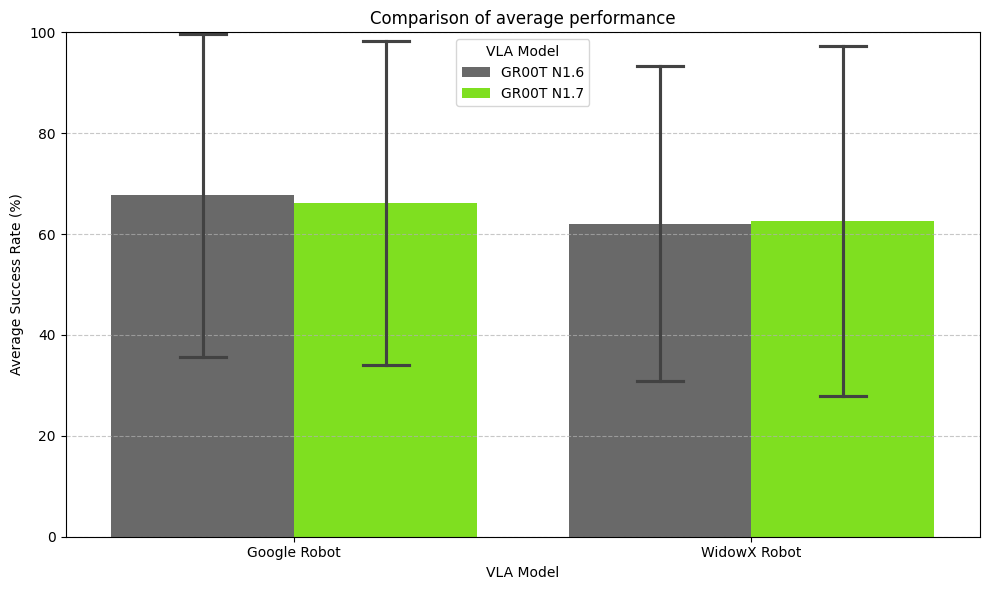

In [24]:
# 2. Gráfico de Barras para Média de Desempenho
# Combine the melted dataframes to use the raw task success rates for calculating mean and std
df_combined_melted = pd.concat([df_google_melted, df_widowx_melted])

plt.figure(figsize=(10, 6))
sns.barplot(data=df_combined_melted, x='robot', y='Taxa de Sucesso', hue='checkpoint', palette={'GR00T N1.7': 'chartreuse', 'GR00T N1.6': 'dimgray'}, errorbar='sd', capsize=0.2)
plt.title('Comparison of average performance')
plt.ylabel('Average Success Rate (%)')
plt.xlabel('VLA Model')
plt.ylim(0, 100)
plt.legend(title='VLA Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

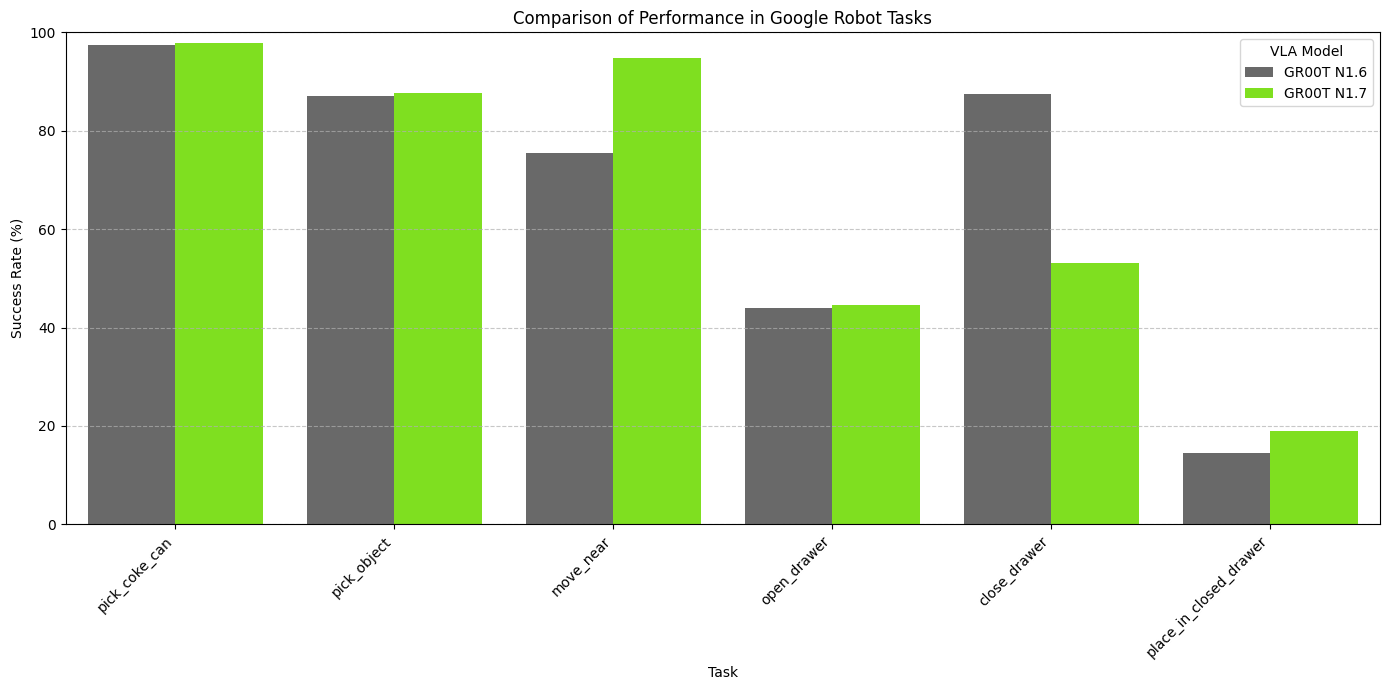

In [23]:
plt.figure(figsize=(14, 7))
sns.barplot(data=df_google_melted, x='Tarefa', y='Taxa de Sucesso', hue='checkpoint', palette={'GR00T N1.7': 'chartreuse', 'GR00T N1.6': 'dimgray'}, errorbar=None)
plt.title('Comparison of Performance in Google Robot Tasks')
plt.ylabel('Success Rate (%)')
plt.xlabel('Task')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.legend(title='VLA Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

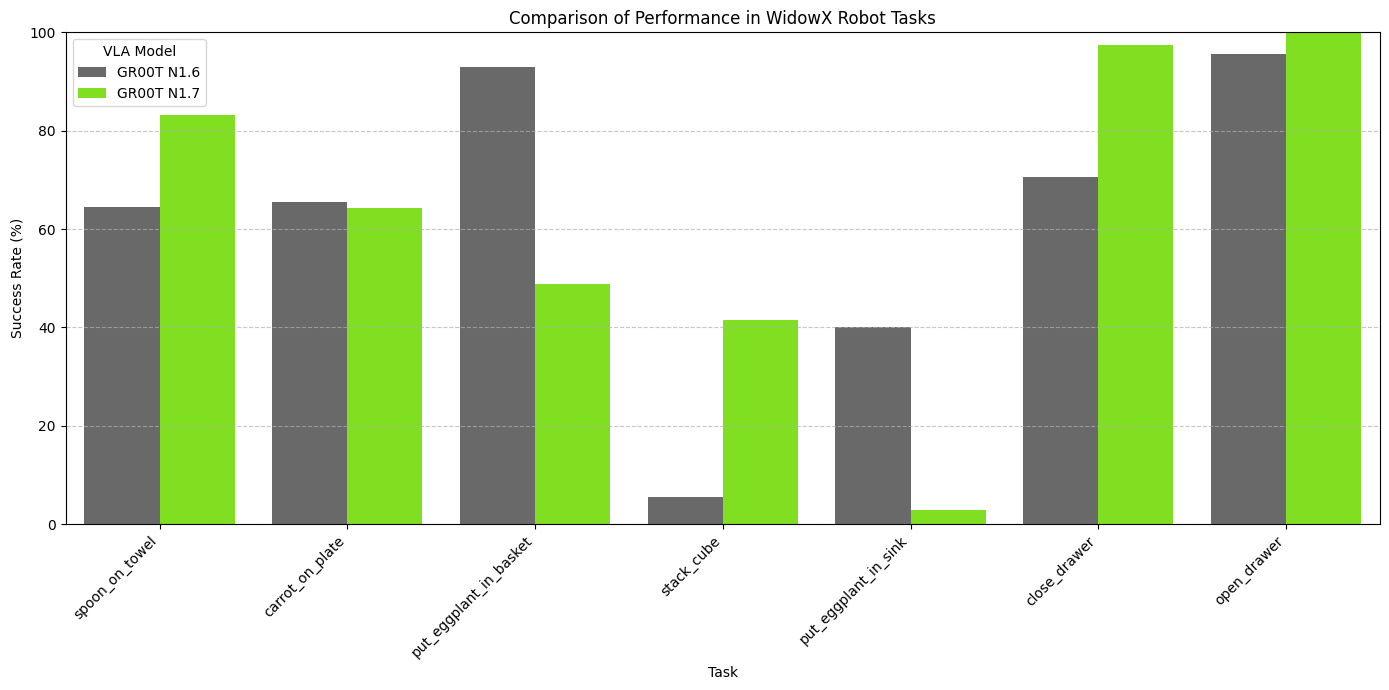

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(data=df_widowx_melted, x='Tarefa', y='Taxa de Sucesso', hue='checkpoint', palette={'GR00T N1.7': 'chartreuse', 'GR00T N1.6': 'dimgray'}, errorbar=None)
plt.title('Comparison of Performance in WidowX Robot Tasks')
plt.ylabel('Success Rate (%)')
plt.xlabel('Task')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.legend(title='VLA Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Visualização dos Dados em Gráficos Radiais/Aranha

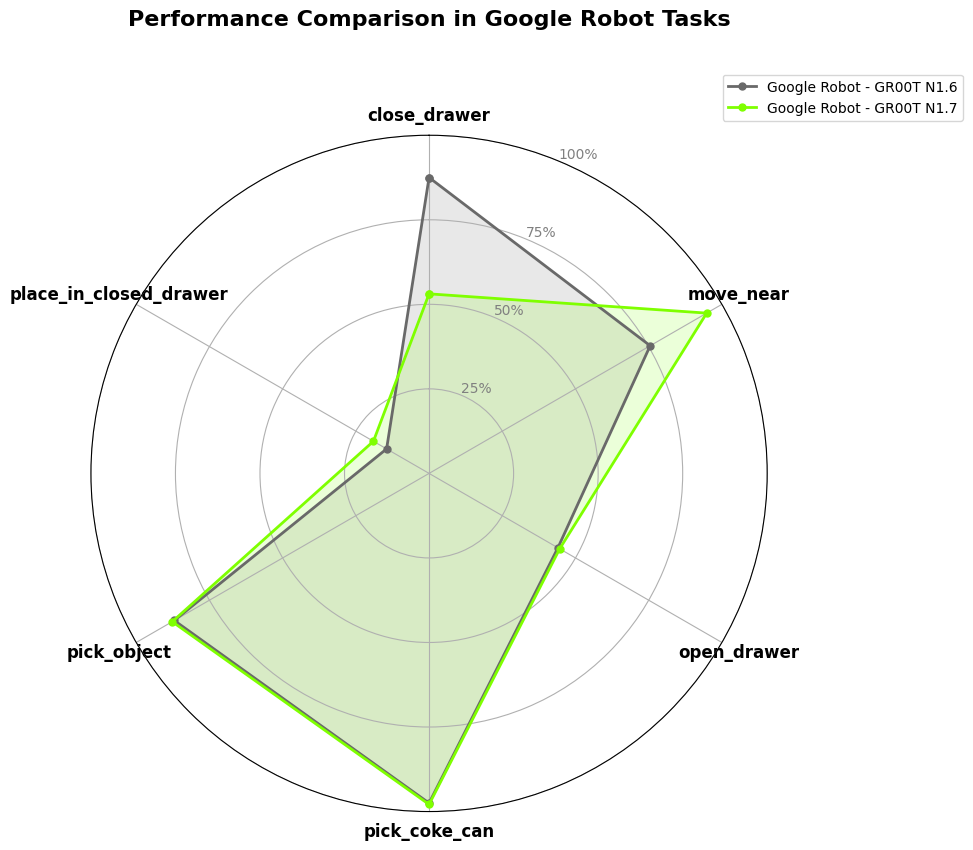

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# The df_google_melted DataFrame is already available and contains the data in a long format.
# Pivot the DataFrame to have tasks as columns and the combination of checkpoint/robô as rows
df_radar_google_tasks = df_google_melted.pivot_table(
    index=['checkpoint', 'robot'],
    columns='Tarefa',
    values='Taxa de Sucesso'
).reset_index()

# Achatamento das colunas (remover o nome do índice das colunas)
df_radar_google_tasks.columns.name = None
df_radar_google_tasks = df_radar_google_tasks.rename_axis(None, axis=1)

# Obter a lista de tarefas (features) que serão os eixos do gráfico
features = df_radar_google_tasks.columns[2:].tolist()
num_features = len(features)

# Calcular o ângulo para cada feature para o layout circular
angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
# Repetir o primeiro ângulo no final para fechar o círculo no gráfico
angles += angles[:1]

# Criar a figura e o subplot polar (gráfico de radar)
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Definir cores para cada combinação de robô e checkpoint para melhor distinção
colors = {
    ('Google Robot', 'GR00T N1.6'): 'dimgray',
    ('Google Robot', 'GR00T N1.7'): 'chartreuse',
}

# Plotar o desempenho de cada modelo (combinação de robô e checkpoint)
for i, row in df_radar_google_tasks.iterrows():
    values = row[features].tolist()
    values += values[:1] # Fechar o círculo no plot

    robot = row['robot']
    checkpoint = row['checkpoint']
    label = f"{robot} - {checkpoint}"
    color = colors.get((robot, checkpoint), 'gray') # Usar cinza como fallback

    ax.plot(angles, values, label=label, color=color, linewidth=2, marker='o', markersize=5)
    ax.fill(angles, values, alpha=0.15, color=color)

# Adicionar rótulos aos eixos do radar
ax.set_theta_offset(np.pi / 2) # Começar no topo
ax.set_theta_direction(-1) # Sentido horário
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=12, weight='bold')

# Configurar limites e rótulos do eixo Y (score)
ax.set_ylim(0, 100) # Assumindo que as pontuações são porcentagens
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], color='gray', size=10)
ax.tick_params(axis='y', colors='gray')
ax.grid(True)

# Adicionar título e legenda
plt.title('Performance Comparison in Google Robot Tasks', size=16, weight='bold', y=1.15)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.show()

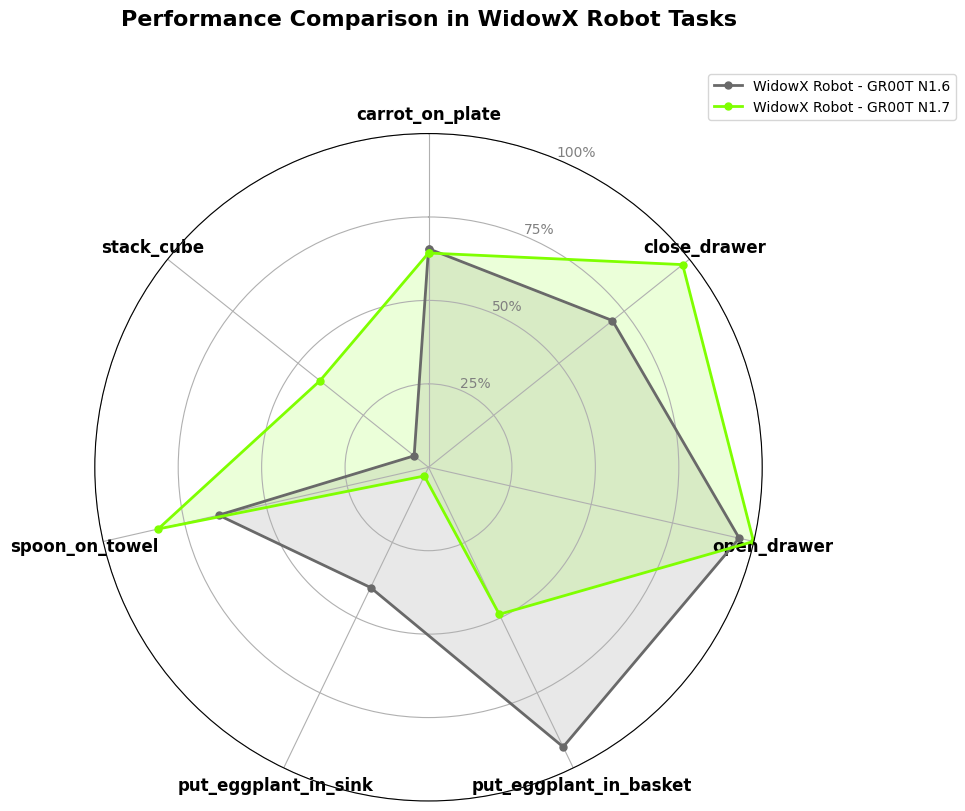

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# The df_google_melted DataFrame is already available and contains the data in a long format.
# Pivot the DataFrame to have tasks as columns and the combination of checkpoint/robô as rows
df_radar_widowx_tasks = df_widowx_melted.pivot_table(
    index=['checkpoint', 'robot'],
    columns='Tarefa',
    values='Taxa de Sucesso'
).reset_index()

# Achatamento das colunas (remover o nome do índice das colunas)
df_radar_widowx_tasks.columns.name = None
df_radar_widowx_tasks = df_radar_widowx_tasks.rename_axis(None, axis=1)

# Obter a lista de tarefas (features) que serão os eixos do gráfico
features = df_radar_widowx_tasks.columns[2:].tolist()
num_features = len(features)

# Calcular o ângulo para cada feature para o layout circular
angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
# Repetir o primeiro ângulo no final para fechar o círculo no gráfico
angles += angles[:1]

# Criar a figura e o subplot polar (gráfico de radar)
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Definir cores para cada combinação de robô e checkpoint para melhor distinção
colors = {
    ('WidowX Robot', 'GR00T N1.6'): 'dimgray',
    ('WidowX Robot', 'GR00T N1.7'): 'chartreuse',
}

# Plotar o desempenho de cada modelo (combinação de robô e checkpoint)
for i, row in df_radar_widowx_tasks.iterrows():
    values = row[features].tolist()
    values += values[:1] # Fechar o círculo no plot

    robot = row['robot']
    checkpoint = row['checkpoint']
    label = f"{robot} - {checkpoint}"
    color = colors.get((robot, checkpoint), 'gray') # Usar cinza como fallback

    ax.plot(angles, values, label=label, color=color, linewidth=2, marker='o', markersize=5)
    ax.fill(angles, values, alpha=0.15, color=color)

# Adicionar rótulos aos eixos do radar
ax.set_theta_offset(np.pi / 2) # Começar no topo
ax.set_theta_direction(-1) # Sentido horário
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=12, weight='bold')

# Configurar limites e rótulos do eixo Y (score)
ax.set_ylim(0, 100) # Assumindo que as pontuações são porcentagens
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], color='gray', size=10)
ax.tick_params(axis='y', colors='gray')
ax.grid(True)

# Adicionar título e legenda
plt.title('Performance Comparison in WidowX Robot Tasks', size=16, weight='bold', y=1.15)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.show()

# Análise Estatística

## Tratamento dos dados para análise estatística

In [ ]:
# Unir o dataframe df_google e df_widowX sem incluir as colunas 'media'

# Criar cópias dos dataframes sem a coluna 'media'
df_google_no_media = df_google.drop(columns=['media'])
df_widowx_no_media = df_widowx.drop(columns=['media'])

# Unir os dataframes baseando-se na coluna 'checkpoint'
# Usar sufixos para diferenciar colunas que podem ter o mesmo nome em ambos os dataframes
df_combined_merged = pd.merge(
    df_google_no_media,
    df_widowx_no_media,
    on='checkpoint',
    how='outer',
    suffixes=('_google', '_widowx')
)

# Remover as colunas 'robot_widowx' e 'robot_google'
df_combined_merged = df_combined_merged.drop(columns=['robot_google', 'robot_widowx'])

# Calcular a diferença entre a primeira e a segunda linha para colunas numéricas
# E adicioná-la como uma nova linha
diff_row = df_combined_merged.iloc[0, 1:] - df_combined_merged.iloc[1, 1:]
diff_row['checkpoint'] = 'Difference (GR00T N1.6 - GR00T N1.7)' # Rótulo para a nova linha

# Converter a série para um DataFrame com uma única linha para concatenação
diff_df = pd.DataFrame([diff_row])

# Adicionar a linha de diferença ao DataFrame combinado
df_combined_merged = pd.concat([df_combined_merged, diff_df], ignore_index=True)

display(df_combined_merged.head())

,checkpoint,pick_coke_can,pick_object,move_near,open_drawer_google,close_drawer_google,place_in_closed_drawer,spoon_on_towel,carrot_on_plate,put_eggplant_in_basket,stack_cube,put_eggplant_in_sink,close_drawer_widowx,open_drawer_widowx
0,GR00T N1.6,97.5,87.0,75.5,44.0,87.5,14.5,64.5,65.5,93.0,5.5,40.0,70.5,95.5
1,GR00T N1.7,97.9,87.7,94.8,44.6,53.1,19.0,83.1,64.2,48.9,41.6,2.9,97.4,99.9
2,Difference (GR00T N1.6 - GR00T N1.7),-0.4,-0.7,-19.3,-0.6,34.4,-4.5,-18.6,1.3,44.1,-36.1,37.1,-26.9,-4.4


## Teste de Wilcoxon

## Teste de Normalidade (Shapiro-Wilk)

O teste de Shapiro-Wilk é usado para verificar se uma amostra de dados foi retirada de uma população normalmente distribuída. A hipótese nula ($H_0$) é que os dados são normalmente distribuídos. Se o p-valor for menor que um nível de significância (comumente 0.05), rejeitamos a hipótese nula e concluímos que os dados não são normalmente distribuídos.

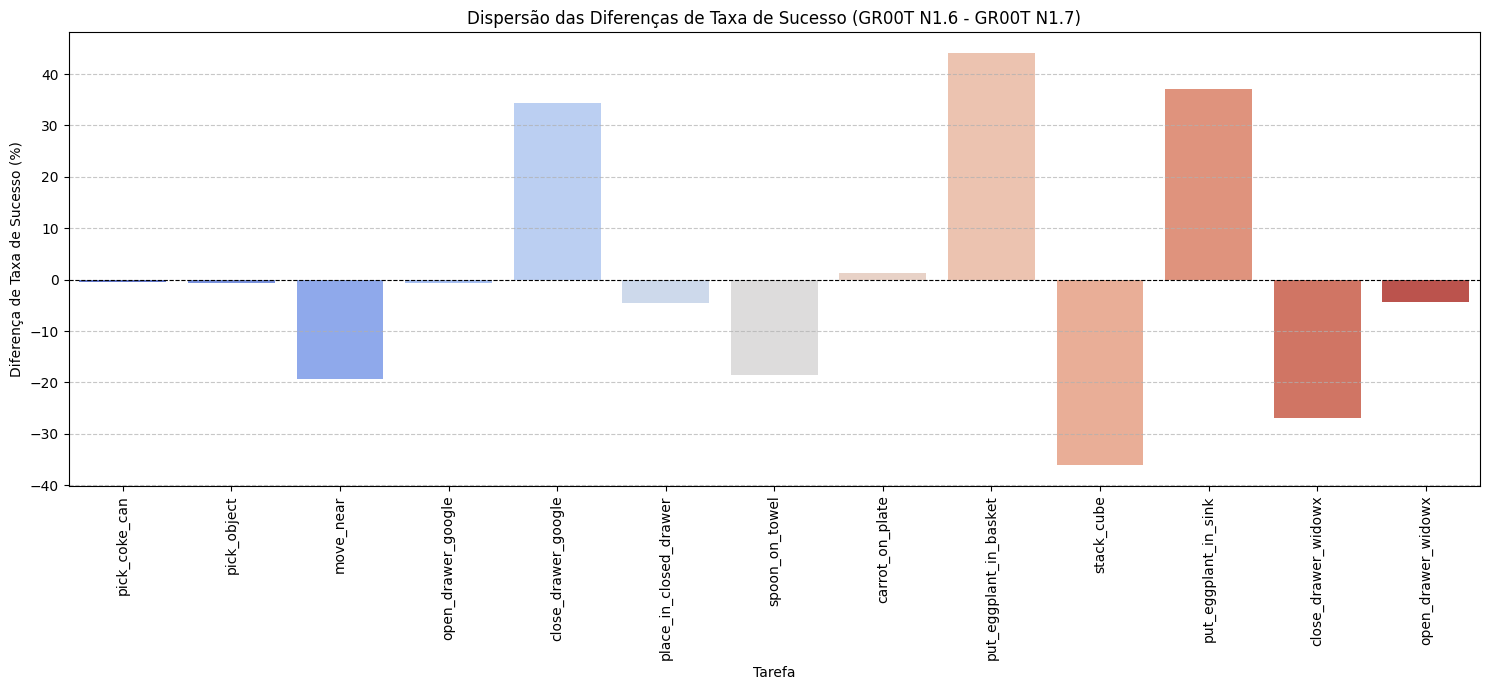

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extrair a linha de diferença (a última linha do DataFrame)
diff_row_data = df_combined_merged.iloc[-1].drop('checkpoint')

# Converter a série para um DataFrame para facilitar a plotagem com seaborn
diff_df_plot = diff_row_data.reset_index()
diff_df_plot.columns = ['Tarefa', 'Diferença de Taxa de Sucesso']

# Certificar-se de que a coluna é numérica para plotagem
diff_df_plot['Diferença de Taxa de Sucesso'] = pd.to_numeric(diff_df_plot['Diferença de Taxa de Sucesso'], errors='coerce').fillna(0)

plt.figure(figsize=(15, 7))
sns.barplot(x='Tarefa', y='Diferença de Taxa de Sucesso', data=diff_df_plot, palette='coolwarm', hue='Tarefa', legend=False)
plt.title('Dispersão das Diferenças de Taxa de Sucesso (GR00T N1.6 - GR00T N1.7)')
plt.xlabel('Tarefa')
plt.ylabel('Diferença de Taxa de Sucesso (%)')
plt.xticks(rotation=90)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # Linha de referência no zero
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats

# A coluna 'Diferença de Taxa de Sucesso' é do tipo object, precisa ser convertida para numérico
diff_df_plot['Diferença de Taxa de Sucesso'] = pd.to_numeric(diff_df_plot['Diferença de Taxa de Sucesso'], errors='coerce')

# Remover quaisquer valores NaN que possam ter sido introduzidos pela conversão
data_for_normality_test = diff_df_plot['Diferença de Taxa de Sucesso'].dropna()

# Realizar o teste de Shapiro-Wilk
shapiro_statistic, shapiro_pvalue = stats.shapiro(data_for_normality_test)

print(f"Shapiro-Wilk Test Statistic: {shapiro_statistic:.3f}")
print(f"Shapiro-Wilk Test p-value: {shapiro_pvalue:.3f}")

alpha = 0.05
if shapiro_pvalue < alpha:
    print(f"Com p-valor ({shapiro_pvalue:.3f}) < {alpha}, rejeitamos a hipótese nula. Os dados NÃO são normalmente distribuídos.")
else:
    print(f"Com p-valor ({shapiro_pvalue:.3f}) >= {alpha}, falhamos em rejeitar a hipótese nula. Os dados SÃO normalmente distribuídos.")

Shapiro-Wilk Test Statistic: 0.906
Shapiro-Wilk Test p-value: 0.160
Com p-valor (0.160) >= 0.05, falhamos em rejeitar a hipótese nula. Os dados SÃO normalmente distribuídos.


O teste de Shapiro-Wilk apontou que há normalidade

## Teste de Normalidade (Kolmogorov-Smirnov)

In [ ]:
from scipy import stats

# Já temos 'data_for_normality_test' do teste de Shapiro-Wilk
# Se não, criar a partir de diff_df_plot novamente
# data_for_normality_test = diff_df_plot['Diferença de Taxa de Sucesso'].dropna()

# Estimar a média e o desvio padrão dos dados para o teste KS contra uma normal
mean_data = data_for_normality_test.mean()
std_data = data_for_normality_test.std()

# Realizar o teste de Kolmogorov-Smirnov
# O parâmetro 'args=(mean_data, std_data)' é para a distribuição normal com média e desvio padrão estimados
ks_statistic, ks_pvalue = stats.kstest(data_for_normality_test, 'norm', args=(mean_data, std_data))

print(f"Kolmogorov-Smirnov Test Statistic: {ks_statistic:.3f}")
print(f"Kolmogorov-Smirnov Test p-value: {ks_pvalue:.3f}")

alpha = 0.05
if ks_pvalue < alpha:
    print(f"Com p-valor ({ks_pvalue:.3f}) < {alpha}, rejeitamos a hipótese nula. Os dados NÃO são normalmente distribuídos.")
else:
    print(f"Com p-valor ({ks_pvalue:.3f}) >= {alpha}, falhamos em rejeitar a hipótese nula. Os dados SÃO normalmente distribuídos.")

Kolmogorov-Smirnov Test Statistic: 0.255
Kolmogorov-Smirnov Test p-value: 0.312
Com p-valor (0.312) >= 0.05, falhamos em rejeitar a hipótese nula. Os dados SÃO normalmente distribuídos.


Kolmogorov também apontou normalidade

## Teste T Pareado nas diferenças de desempenho

In [ ]:
from scipy import stats

# Extrair as linhas correspondentes a GR00T N1.6 e GR00T N1.7 do df_combined_merged
# Excluir a coluna 'checkpoint' para pegar apenas os valores numéricos das tarefas
scores_n1_6 = df_combined_merged[df_combined_merged['checkpoint'] == 'GR00T N1.6'].drop(columns='checkpoint').iloc[0]
scores_n1_7 = df_combined_merged[df_combined_merged['checkpoint'] == 'GR00T N1.7'].drop(columns='checkpoint').iloc[0]

# Converter para tipo numérico, tratando possíveis erros
scores_n1_6 = pd.to_numeric(scores_n1_6, errors='coerce')
scores_n1_7 = pd.to_numeric(scores_n1_7, errors='coerce')

# Remover NaNs que podem ter sido gerados pela conversão ou existiam originalmente
df_temp = pd.DataFrame({'n1_6': scores_n1_6, 'n1_7': scores_n1_7}).dropna()

scores_n1_6_clean = df_temp['n1_6'].values
scores_n1_7_clean = df_temp['n1_7'].values

# Realizar o teste t pareado
t_statistic_paired, p_value_paired = stats.ttest_rel(scores_n1_6_clean, scores_n1_7_clean)

print(f"Paired t-test Statistic: {t_statistic_paired:.3f}")
print(f"Paired t-test p-value: {p_value_paired:.3f}")

alpha = 0.05
if p_value_paired < alpha:
    print(f"Com p-valor ({p_value_paired:.3f}) < {alpha}, rejeitamos a hipótese nula. Há uma diferença estatisticamente significativa entre as taxas de sucesso dos checkpoints GR00T N1.6 e GR00T N1.7.")
else:
    print(f"Com p-valor ({p_value_paired:.3f}) >= {alpha}, falhamos em rejeitar a hipótese nula. Não há evidência de uma diferença estatisticamente significativa entre as taxas de sucesso dos checkpoints GR00T N1.6 e GR00T N1.7.")

Paired t-test Statistic: 0.061
Paired t-test p-value: 0.953
Com p-valor (0.953) >= 0.05, falhamos em rejeitar a hipótese nula. Não há evidência de uma diferença estatisticamente significativa entre as taxas de sucesso dos checkpoints GR00T N1.6 e GR00T N1.7.


Não há diferença estatística